# Data Science In Action



# Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
from statsmodels.stats.rates import test_poisson_2indep


## Data Load

In [2]:
cahoot_2015 = pd.read_csv("EPD_data/EugeneCAD2015noloc.csv", low_memory=False)
cahoot_2016 = pd.read_csv("EPD_data/EugeneCAD2016noloc.csv", low_memory=False)
cahoot_2017 = pd.read_csv("EPD_data/EugeneCAD2017noloc.csv", low_memory=False)
cahoot_2018 = pd.read_csv("EPD_data/EugeneCAD2018noloc.csv", low_memory=False)
cahoot_2019 = pd.read_csv("EPD_data/EugeneCAD2019noloc.csv", low_memory=False)
cahoot_2020 = pd.read_csv("EPD_data/EugeneCAD2020noloc.csv", low_memory=False)
cahoot_2021 = pd.read_csv("EPD_data/EugeneCAD2021noloc.csv", low_memory=False)
cahoot_2022 = pd.read_csv("EPD_data/EugeneCAD2022noloc.csv", low_memory=False)
cahoot_2023 = pd.read_csv("EPD_data/EugeneCAD2023noloc.csv", low_memory=False)
cahoot_2024 = pd.read_csv("EPD_data/EugeneCAD2024noloc.csv", low_memory=False)
cahoot_2025 = pd.read_csv("EPD_data/EugeneCAD2025noloc.csv", low_memory=False)

mcls = pd.read_excel("MCSLC.xlsx", sheet_name="Abbrev list")

print("CAHOOTS row counts by year (raw):")
for y, d in [(2015,cahoot_2015),(2016,cahoot_2016),(2017,cahoot_2017),(2018,cahoot_2018),
             (2019,cahoot_2019),(2020,cahoot_2020),(2021,cahoot_2021),(2022,cahoot_2022),
             (2023,cahoot_2023),(2024,cahoot_2024),(2025,cahoot_2025)]:
    print(f"  {y}: {len(d):>7,}  agencies: {sorted(d['agency'].astype(str).str.strip().unique())}")
print(f"\nMCLS rows: {len(mcls):,}")

CAHOOTS row counts by year (raw):
  2015: 123,248  agencies: ['EPD']
  2016: 127,732  agencies: ['EPD']
  2017: 129,688  agencies: ['EPD']
  2018: 127,432  agencies: ['EPD']
  2019: 137,089  agencies: ['EPD']
  2020: 137,287  agencies: ['EPD']
  2021: 137,527  agencies: ['EPD']
  2022: 140,545  agencies: ['CAHE', 'EPD']
  2023: 135,464  agencies: ['CAHE', 'EPD']
  2024: 132,650  agencies: ['CAHE', 'EPD']
  2025: 117,352  agencies: ['CAHE', 'EPD']

MCLS rows: 4,682


## Cahoot Clean

In [3]:
def clean_cahoots(df):
    df = df.copy()
    for col in ["agency", "nature", "closecode", "closed_as", "prime_unit"]:
        if col in df.columns:
            df[col] = df[col].astype("string").str.strip()
    df = df[df["agency"] == "CAHE"].reset_index(drop=True)
    return df

cahoot_2015 = clean_cahoots(cahoot_2015)
cahoot_2016 = clean_cahoots(cahoot_2016)
cahoot_2017 = clean_cahoots(cahoot_2017)
cahoot_2018 = clean_cahoots(cahoot_2018)
cahoot_2019 = clean_cahoots(cahoot_2019)
cahoot_2020 = clean_cahoots(cahoot_2020)
cahoot_2021 = clean_cahoots(cahoot_2021)
cahoot_2022 = clean_cahoots(cahoot_2022)
cahoot_2023 = clean_cahoots(cahoot_2023)
cahoot_2024 = clean_cahoots(cahoot_2024)
cahoot_2025 = clean_cahoots(cahoot_2025)

print("CAHOOTS row counts by year with filter:")
for y, d in [(2015, cahoot_2015),(2016,cahoot_2016),(2017,cahoot_2017),(2018,cahoot_2018),
             (2019,cahoot_2019),(2020,cahoot_2020),(2021,cahoot_2021),(2022,cahoot_2022),
             (2023,cahoot_2023),(2024,cahoot_2024),(2025,cahoot_2025)]:
    print(f"  cahoot_{y}: {len(d):>6,}")

CAHOOTS row counts by year with filter:
  cahoot_2015:      0
  cahoot_2016:      0
  cahoot_2017:      0
  cahoot_2018:      0
  cahoot_2019:      0
  cahoot_2020:      0
  cahoot_2021:      0
  cahoot_2022: 15,135
  cahoot_2023: 18,121
  cahoot_2024: 17,254
  cahoot_2025:  4,624


## MCLS Clean

In [4]:
mcls = mcls[["ID", "End Point of Dispatch", "Reason for Dispatch #1", "Disposition"]].copy()

mcls["End Point of Dispatch"]  = mcls["End Point of Dispatch"].astype("string").str.strip()
mcls["Reason for Dispatch #1"] = mcls["Reason for Dispatch #1"].astype("string").str.strip()
mcls["Disposition"] = mcls["Disposition"].astype("string").str.strip()


print(f"MCLS rows: {len(mcls):,}")
print("Columns:", list(mcls.columns))
print("\nDisposition value counts:")
print(mcls["Disposition"].value_counts(dropna=False))

MCLS rows: 4,682
Columns: ['ID', 'End Point of Dispatch', 'Reason for Dispatch #1', 'Disposition']

Disposition value counts:
Disposition
Remained in community         3750
Emergency Department           652
Other                          230
Sobering/Detox Facility         26
Arrest                          16
Crisis walk-in Center            3
Respite                          3
Sobering or Detox Facility       2
Name: count, dtype: Int64


## Build EPD_handoff - Cahoots

In [5]:
handoff_values = {
    "REFERRED TO OTHER AGENCY",
    "RELAYED TO LANE COUNTY SHERIFFS OFFICE",
    "RELAYED TO OREGON STATE POLICE",
    "UNIFORM TRAFFIC CITATION ISSUED",
}

def add_cahoots_handoff(df):
    df = df.copy()
    df["epd_handoff"] = df["closed_as"].isin(handoff_values).astype(int)
    return df

df_2022 = add_cahoots_handoff(cahoot_2022)
df_2023 = add_cahoots_handoff(cahoot_2023)
df_2024 = add_cahoots_handoff(cahoot_2024)
df_2025 = add_cahoots_handoff(cahoot_2025)

audit = pd.concat([df_2022, df_2023, df_2024, df_2025], ignore_index=True)
print("CAHOOTS closed_as × epd_handoff (2022–2025 combined):")
print(pd.crosstab(audit["closed_as"], audit["epd_handoff"], margins=True))

CAHOOTS closed_as × epd_handoff (2022–2025 combined):
epd_handoff                                 0    1    All
closed_as                                                
ACCIDENTALLY CHOSE NEW EVENT               71    0     71
ADVISED                                   294    0    294
ANIMAL WELFARE OFFICER                      1    0      1
ASSISTED                                25555    0  25555
CALLER CALLED BACK                        311    0    311
CALLER WILL CALL BACK                     204    0    204
CANCEL FIRE UNIT FROM CALL                  1    0      1
CANCEL WHILE ENROUTE                        1    0      1
DEAD ON ARRIVAL                             1    0      1
DISREGARD                                7552    0   7552
DISREGARDED BY DISPATCH                   743    0    743
DISREGARDED BY PATROL SUPERVISOR            4    0      4
EXECUTIVE ORDER 2012 VIOLATION              1    0      1
FALSE ALARM                                 3    0      3
FOLLOW UP INVESTIG

## Build EPD_handoff - MCLS

In [6]:
mcls["epd_handoff"] = (mcls["Disposition"] == "Arrest").astype(int)

print("MCLS Disposition × epd_handoff:")
print(pd.crosstab(mcls["Disposition"], mcls["epd_handoff"], margins=True))
print(f"\nTotal handoffs: {mcls['epd_handoff'].sum():,} of {len(mcls):,} "
      f"({mcls['epd_handoff'].mean():.2%})")

MCLS Disposition × epd_handoff:
epd_handoff                    0   1   All
Disposition                               
Arrest                         0  16    16
Crisis walk-in Center          3   0     3
Emergency Department         652   0   652
Other                        230   0   230
Remained in community       3750   0  3750
Respite                        3   0     3
Sobering or Detox Facility     2   0     2
Sobering/Detox Facility       26   0    26
All                         4666  16  4682

Total handoffs: 16 of 4,682 (0.34%)


# RQ1 - Handoff Rate Summary

In [7]:
cahoots_all = pd.concat([df_2022, df_2023, df_2024, df_2025], ignore_index=True)

# Calculate CAHOOTS handoff rate
n_calls_cahoots = len(cahoots_all)
n_handoffs_cahoots = cahoots_all["epd_handoff"].sum()
rate_cahoots = n_handoffs_cahoots / n_calls_cahoots

# Calculate MCLS handoff rate
n_calls_mcls = len(mcls)
n_handoffs_mcls = mcls["epd_handoff"].sum()
rate_mcls = n_handoffs_mcls / n_calls_mcls

summary = pd.DataFrame({
    "prohram" : ["CAHOOTS (2022–2025)", "MCLS"],
    "n_calls": [n_calls_cahoots, n_calls_mcls],
    "n_handoffs": [n_handoffs_cahoots, n_handoffs_mcls],
    "handoff_rate": [rate_cahoots, rate_mcls],
})

summary["handoff_pct"] = (summary["handoff_rate"] * 100).round(2).astype(str) + "%"

print("Handoff rate summary:")
print(summary.to_string(index=False))

Handoff rate summary:
            prohram  n_calls  n_handoffs  handoff_rate handoff_pct
CAHOOTS (2022–2025)    55134         753      0.013658       1.37%
               MCLS     4682          16      0.003417       0.34%


# Two Sample Z-Test

In [12]:
counts = np.array([n_handoffs_cahoots, n_handoffs_mcls])
nobs = np.array([n_calls_cahoots, n_calls_mcls])

z_stat, p_value = proportions_ztest(counts, nobs, alternative="two-sided")

diff_pp = (rate_cahoots - rate_mcls) * 100

print(f"CAHOOTS handoff rate: {rate_cahoots:.4%} ({n_handoffs_cahoots:,} / {n_calls_cahoots:,})")
print(f"MCLS handoff rate: {rate_mcls:.4%}  ({n_handoffs_mcls:,} / {n_calls_mcls:,})")
print(f"Absolute difference: {diff_pp:+.2f} percentage points")
print()
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4g}")
print()

CAHOOTS handoff rate: 1.3658% (753 / 55,134)
MCLS handoff rate: 0.3417%  (16 / 4,682)
Absolute difference: +1.02 percentage points

z-statistic: 5.9715
p-value: 2.351e-09



# RQ1 - Figure 1: Handoff Rate by Program

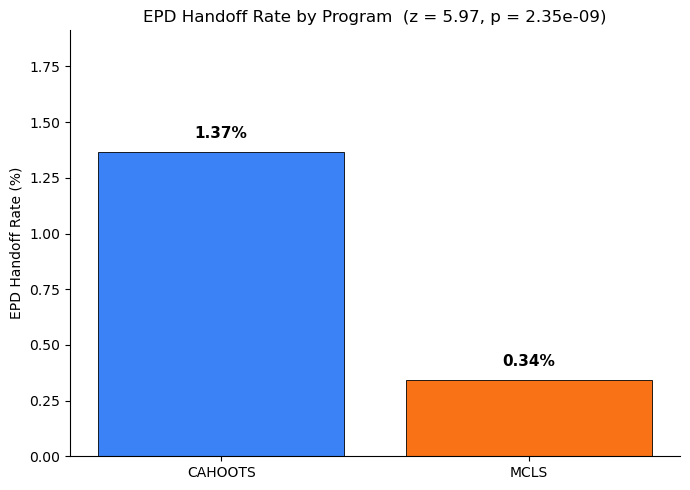

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

programs = ["CAHOOTS", "MCLS"]
rates_pct = [rate_cahoots * 100, rate_mcls * 100]
colors = ["#3b82f6", "#f97316"]

bars = ax.bar(programs, rates_pct, color=colors, edgecolor="black", linewidth=0.6)

for bar, pct in zip(bars, rates_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{pct:.2f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("EPD Handoff Rate (%)")
ax.set_title(f"EPD Handoff Rate by Program  (z = {z_stat:.2f}, p = {p_value:.3g})")
ax.set_ylim(0, max(rates_pct) * 1.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# RQ1 Findings

Cahoots handed off **1.37%** of its calls to law enforcement (753 of 55,134), while MCLS handed off **0.34%** (16 of 4,682). The two sample z-test for proportions returned z = 5.97, p ≈ 2.4 X 10 ^-9. At α - 0.05, we reject the null the two rates are statistically different. 

In absolute terms the gap is only about **1 percentage point**, but in relative term Cahoots hands off roughly **4x as often** as MCLS. Comparing the 2 either way is useful. The absolute gap shows the operational reality, which is that handoffs are rare in both programs. The relative gap shows that CAHOOTS is more likely to escalate per call. 

Both of the programs define "EPD invovement" differently in their data. CAHOOTS handoff signal comes from explicit close codes for relays and referrals. Whilr MCLS is narrower, such as only formal arrest, since MCLS has no arrest authority. Some of the rate gap likely reflects the difference rather than a pure operational difference

# RQ2 - Adding date and city columns to MCLS

In [12]:
# Reload the original Excel to pull date and city back in
mcls_raw = pd.read_excel("MCSLC.xlsx", sheet_name="Abbrev list")

# Attach date and city to the existing cleaned mcls frame using ID as the key
mcls = mcls.merge(
    mcls_raw[["ID", "Dispatch Request Date & Time", "City"]],
    on="ID",
    how="left",
)

# Strip whitespace on the new city column
mcls["City"] = mcls["City"].astype("string").str.strip()

# Parse the date column
mcls["dispatch_date"] = pd.to_datetime(mcls["Dispatch Request Date & Time"], errors="coerce")

# CAHOOTS Eugene services ended April 7, 2025
CAHOOTS_END_DATE = pd.Timestamp("2025-04-07")
mcls["period"] = np.where(mcls["dispatch_date"] < CAHOOTS_END_DATE, "pre", "post")
mcls.loc[mcls["dispatch_date"].isna(), "period"] = pd.NA

# Group cities into the analysis-relevant buckets
def assign_city_group(c):
    if pd.isna(c):
        return "Unknown"
    if c == "Eugene":
        return "Eugene"
    if c == "Springfield":
        return "Springfield"
    if c in ("Other", "Out of County"):
        return "Other Lane County"
    return "Unknown"

mcls["city_group"] = mcls["City"].apply(assign_city_group)

print(f"MCLS rows: {len(mcls):,}")
print(f"Date range: {mcls['dispatch_date'].min()} → {mcls['dispatch_date'].max()}")
print(f"Rows with valid dates: {mcls['dispatch_date'].notna().sum():,}")
print()
print("Period distribution:")
print(mcls["period"].value_counts(dropna=False))
print()
print("City group distribution:")
print(mcls["city_group"].value_counts(dropna=False))
print()
print("Period × city_group:")
print(pd.crosstab(mcls["period"], mcls["city_group"], margins=True, dropna=False))

MCLS rows: 4,682
Date range: 2024-08-18 14:12:00 → 2025-12-17 04:59:18
Rows with valid dates: 4,605

Period distribution:
period
post    3802
pre      803
<NA>      77
Name: count, dtype: int64

City group distribution:
city_group
Eugene               3630
Other Lane County     520
Springfield           362
Unknown               170
Name: count, dtype: int64

Period × city_group:
city_group  Eugene  Other Lane County  Springfield  Unknown     All
period                                                             
post          3014                355          282      151  3802.0
pre            560                159           75        9   803.0
NaN             56                  6            5       10     NaN
All           3630                520          362      170  4682.0


# MCLS Dispostion Pre vs Post

In [13]:

eug = mcls[(mcls["city_group"] == "Eugene") & mcls["period"].notna()]
ct = pd.crosstab(eug["period"], eug["Disposition"]).reindex(["pre", "post"]).fillna(0).astype(int)
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)

print("Disposition share within each period (%):")
print(pct.to_string())

ct_clean = ct.loc[:, (ct > 0).all(axis=0)]
chi2, p, dof, _ = chi2_contingency(ct_clean)
print(f"\nchi2 = {chi2:.2f}, df = {dof}, p = {p:.4g}")

Disposition share within each period (%):
Disposition  Arrest  Crisis walk-in Center  Emergency Department  Other  Remained in community  Respite  Sobering or Detox Facility  Sobering/Detox Facility
period                                                                                                                                                      
pre            0.36                    0.0                 15.36   3.39                  79.64      0.0                        0.36                     0.89
post           0.33                    0.1                 13.24   4.45                  81.15      0.1                        0.00                     0.63

chi2 = 3.42, df = 4, p = 0.4909


## RQ2 - Daily Call Volume: CAHOOTS, MCLS, EPD

April 2025 is excluded because the 2025 CAD data is only month-resolved and CAHOOTS ended mid-month.

In [15]:

EPD_CRISIS = {"CHECK WELFARE", "DISORDERLY SUBJECT", "SUICIDAL SUBJECT", "OVERDOSE",
              "INTOXICATED SUBJECT", "DISORIENTED SUBJECT", "PUBLIC ASSIST", "TRANSPORT"}

df24 = pd.read_csv("EPD_data/EugeneCAD2024noloc.csv", low_memory=False)
df24["agency"] = df24["agency"].astype("string").str.strip()
df24["nature"] = df24["nature"].astype("string").str.strip()
df24["calltime_dt"] = pd.to_datetime(df24["calltime"], errors="coerce")
df24 = df24[df24["calltime_dt"] >= pd.Timestamp("2024-08-01")].copy()
df24["period"] = "pre"

df25 = pd.read_csv("EPD_data/EugeneCAD2025noloc.csv", low_memory=False)
df25["agency"] = df25["agency"].astype("string").str.strip()
df25["nature"] = df25["nature"].astype("string").str.strip()
df25["period"] = df25["month"].map(lambda m: "pre" if m in (1,2,3) else ("post" if m >= 5 else pd.NA))
df25 = df25[df25["period"].notna()].copy()

cad = pd.concat([df24, df25], ignore_index=True)
cahoots_w = cad[cad["agency"] == "CAHE"]
epd_w = cad[(cad["agency"] == "EPD") & (cad["nature"].isin(EPD_CRISIS))]
mcls_w = mcls[(mcls["city_group"] == "Eugene") & mcls["period"].notna() &
                 ~((mcls["dispatch_date"] >= pd.Timestamp("2025-04-01")) &
                   (mcls["dispatch_date"] <  pd.Timestamp("2025-05-01")))]

pre_days  = (pd.Timestamp("2025-04-01") - pd.Timestamp("2024-08-01")).days
post_days = (pd.Timestamp("2025-12-31") - pd.Timestamp("2025-05-01")).days

def vol(df, name):
    pre  = (df["period"] == "pre").sum()
    post = (df["period"] == "post").sum()
    p = test_poisson_2indep(pre, pre_days, post, post_days, method="score").pvalue if pre and post else float("nan")
    return {"program": name, "pre_per_day": round(pre/pre_days, 2),
            "post_per_day": round(post/post_days, 2),
            "ratio": round((post/post_days)/(pre/pre_days), 2) if pre else float("nan"),
            "p_value": p}

vol_df = pd.DataFrame([vol(cahoots_w, "CAHOOTS"), vol(mcls_w, "MCLS"), vol(epd_w, "EPD crisis")])
print(vol_df.to_string(index=False))

   program  pre_per_day  post_per_day  ratio      p_value
   CAHOOTS        46.85          0.00   0.00          NaN
      MCLS         2.22         11.52   5.18 0.000000e+00
EPD crisis        26.94         33.48   1.24 2.232179e-39


# Call Volume Plot

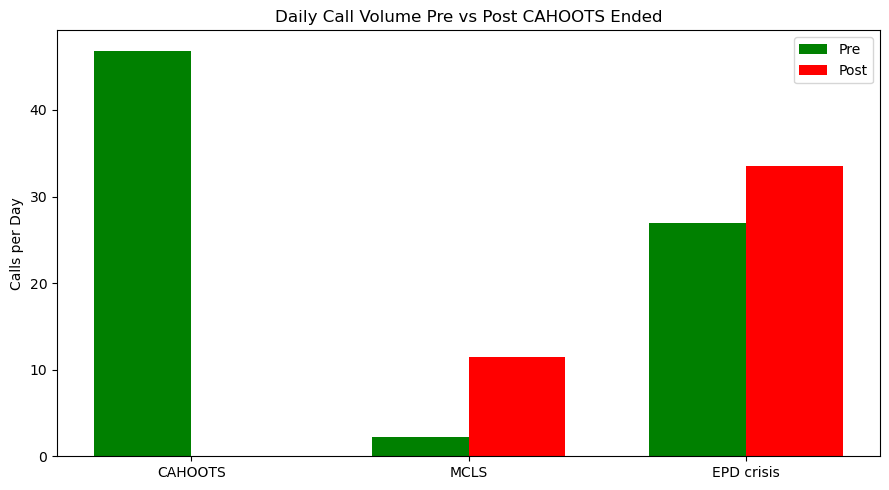

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(vol_df))
w = 0.35
ax.bar(x - w/2, vol_df["pre_per_day"],  w, label="Pre",  color="green")
ax.bar(x + w/2, vol_df["post_per_day"], w, label="Post", color="red")
ax.set_xticks(x)
ax.set_xticklabels(vol_df["program"])
ax.set_ylabel("Calls per Day")
ax.set_title("Daily Call Volume Pre vs Post CAHOOTS Ended")
ax.legend()
plt.tight_layout()
plt.show()

## RQ2 - EPD Crisis Call-Type Mix

In [17]:
top = epd_w["nature"].value_counts().head(8).index.tolist()
sub = epd_w[epd_w["nature"].isin(top)]
ct = pd.crosstab(sub["period"], sub["nature"]).reindex(["pre", "post"]).fillna(0).astype(int)
pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)

print("EPD crisis call mix (% within period):")
print(pct.to_string())

chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nchi2 = {chi2:.2f}, df = {dof}, p = {p:.4g}")

EPD crisis call mix (% within period):
nature  CHECK WELFARE  DISORDERLY SUBJECT  DISORIENTED SUBJECT  INTOXICATED SUBJECT  OVERDOSE  SUICIDAL SUBJECT  TRANSPORT
period                                                                                                                    
pre             44.04               30.78                 0.75                 0.92      9.09             13.32       1.12
post            55.46               24.85                 1.20                 1.03      6.35             10.24       0.87

chi2 = 216.28, df = 6, p = 6.448e-44


# Call Type Plot

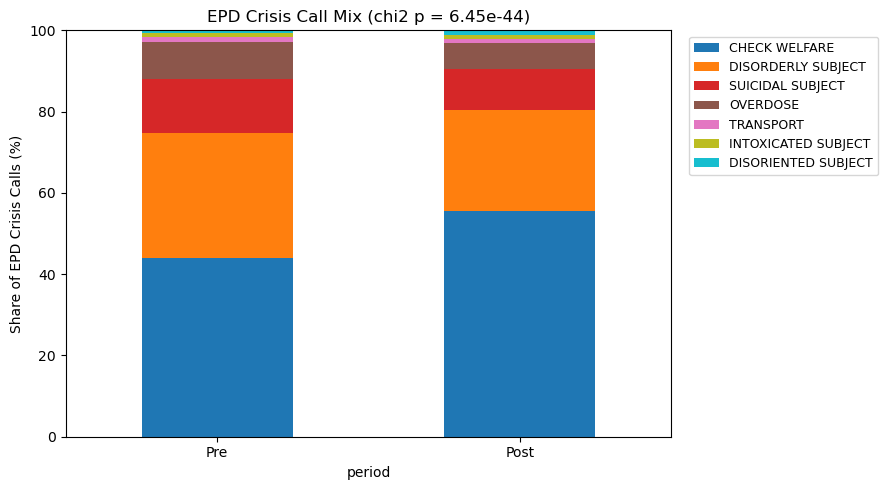

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
col_order = pct.sum(axis=0).sort_values(ascending=False).index.tolist()
pct[col_order].plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("Share of EPD Crisis Calls (%)")
ax.set_xticklabels(["Pre", "Post"], rotation=0)
ax.set_title(f"EPD Crisis Call Mix (chi2 p = {p:.3g})")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# RQ2 Findings

When CAHOOTS stopped servinf Eugene on April 7, 2025, the calls they used to handle didn't disapper. They got picked up by MCLS and EPD instead. MCLS dispatches in Eugene jumped from about 2.2 calls per day to 11.4 whicch in an increase of 5.18x (Poisson rate ratio test, p < 0.001). EPD also picked up volume on its crisis calls. It grew more modestly 1.24x from 26.9 to 33.5 calls per day (p < 0.001). EPD also told another story as the mix of crisis calls theu responded to shifted signifcantly, with "CHECK WELFARE" growing from 44% to 55% (chi-square p < 0.001). MCLS absorbed a large share of the volume without changing how they operate, while EPD had to absorb a different slice of CAHOOTS former workload